In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("../data/raw/Credit_Card_Applications.csv")

In [32]:
df.head() #What does the data look like?

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [33]:
df.shape #How big is the dataset?

(690, 16)

In [34]:
df.info() #What are the column types?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [35]:
df.isnull().sum() #Are there missing values?

CustomerID    0
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
A11           0
A12           0
A13           0
A14           0
Class         0
dtype: int64

In [36]:
df.duplicated().sum() #Are there duplicate rows?

0

In [37]:
df["Class"].value_counts() #Is the target balanced?

Class
0    383
1    307
Name: count, dtype: int64

In [38]:
df.describe() #What are the summary statistics?

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,6.900000e+02,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,1.569047e+07,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,7.150647e+04,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,1.556571e+07,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1.563169e+07,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.569016e+07,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.575190e+07,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.581544e+07,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


### A14 investigation

In [23]:
df["A14"].nunique()

240

In [24]:
df["A14"].describe()

count       690.000000
mean       1018.385507
std        5210.102598
min           1.000000
25%           1.000000
50%           6.000000
75%         396.500000
max      100001.000000
Name: A14, dtype: float64

In [25]:
df["A14"].head(20)

0     1213
1        1
2        1
3        1
4      159
5        1
6      101
7      561
8      538
9       51
10     858
11       1
12     211
13    1001
14       1
15    2691
16       1
17     592
18       5
19    3258
Name: A14, dtype: int64

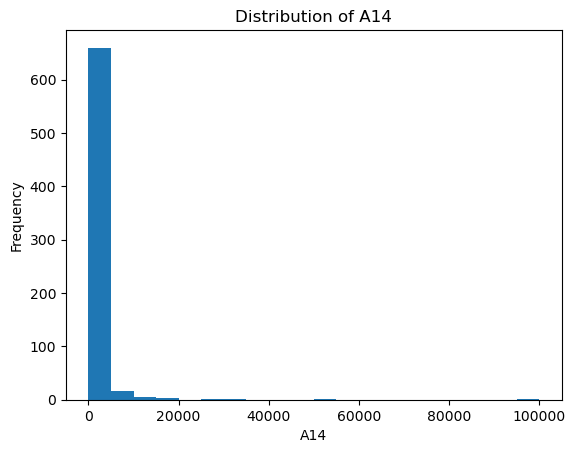

In [28]:
import matplotlib.pyplot as plt

#reveal whether the values are spread continuously or clustered.
plt.hist(df["A14"], bins=20)
plt.title("Distribution of A14")
plt.xlabel("A14")
plt.ylabel("Frequency")
plt.show()

In [29]:
df.groupby("Class")["A14"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,383.0,199.605744,671.608839,1.0,1.0,2.0,68.0,5553.0
1,307.0,2039.859935,7659.763941,1.0,1.0,222.0,1210.0,100001.0


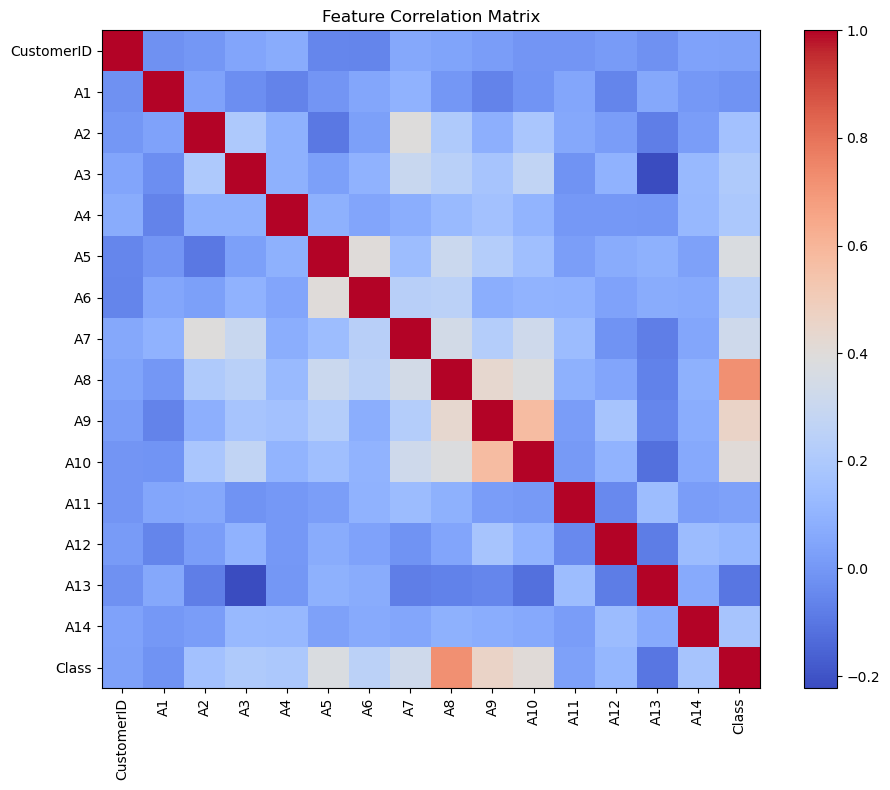

In [30]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Data Assessment and Preprocessing Decisions

The dataset was inspected before preprocessing to evaluate its quality and suitability for machine learning.

### Findings

* The dataset contains **690 observations** and **16 columns**.
* No missing values were found.
* No duplicate rows were detected.
* All features have appropriate numeric data types (`int64` or `float64`).
* The target variable (`Class`) is reasonably balanced, with **383 rejected** and **307 approved** applications.

### Investigation of Feature A14

Although the available documentation suggested that **A14** could represent either a ZIP code or a financial value, further analysis showed that:

* It contains **240 unique values**, indicating that it is not a unique identifier.
* Its distribution is **strongly right-skewed**.
* It differs substantially between the two target classes:

  * Median for rejected applications: **2**
  * Median for approved applications: **222**

These observations suggest that **A14** contains useful predictive information, so it was retained for model training.

### Preprocessing Decisions

* `CustomerID` will be removed because it is a unique identifier and does not provide useful predictive information.
* `Class` will be used as the target variable.
* All remaining features, including `A14`, will be retained for model training.
